### MOMM PROJECT


## 🌐 **Google Drive Connection**

In [61]:
# from google.colab import drive
# drive.mount("/gdrive")
# current_dir = "/gdrive/My\\ Drive//MolModMaterialsProject/MMOM-project"
# %cd $current_dir

## ⚙️ **Libraries Import**

In [62]:
# !pip install numba-progress
# !pip install torchsummary
# !pip install tensorboard
# !pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import random
import numpy as np
from datetime import datetime

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(SEED)
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from numba import njit, prange
from tqdm.auto import tqdm

logs_dir = "networks"

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from lammps import lammps
from extract_dump import parse_lammps_dump_to_csv
import glob


PyTorch version: 2.12.1
Device: mps


## 🐱 **Hyperparameters**

In [63]:
BATCH_SIZE = 128

# Model architecture configuration
HIDDEN_LAYERS = 2
HIDDEN_SIZE   = 64
DROPOUT_RATE = 0.0

LEARNING_RATE = 1e-4
EPOCHS = 1500
PATIENCE = 75
L2_LAMBDA = 0.0


N_RADIAL = 32
N_ANGULAR = 16

## ⏳ **Data Loading**

In [64]:
os.makedirs("Si_dataset", exist_ok=True)

In [65]:
# ============================================================
# Common LAMMPS initialization
# ============================================================

def setup_lammps():
    # Force Python to find the correct DLLs in the LAMMPS installation folder
    lammps_bin = r"C:\Users\giorg\AppData\Local\LAMMPS 64-bit 22Jul2025-MSMPI with Python\bin"
    
    if os.path.exists(lammps_bin):
        os.add_dll_directory(lammps_bin)
    
    lmp = lammps()

    cmds = """

    units metal
    dimension 3
    boundary p p p
    atom_style atomic


    lattice diamond 5.431

    region box block 0 2 0 2 0 2

    create_box 1 box
    create_atoms 1 box


    mass 1 28.0855


    pair_style sw
    pair_coeff * * Si.sw Si


    timestep 0.001


    compute eatom all pe/atom


    thermo 1000
    thermo_style custom step temp pe etotal press


    """

    lmp.commands_string(cmds)

    return lmp



# ============================================================
# Save dataset snapshot
# ============================================================

def setup_dump(lmp, filename):

    lmp.commands_string(f"""

    dump d1 all custom 1000 Si_dataset/{filename} \
    id type x y z fx fy fz c_eatom

    dump_modify d1 sort id

    """)


# ============================================================
# 1) Perfect crystal at 300K
# ============================================================

def crystal():

    if os.path.exists("Si_dataset/crystal.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"crystal.dump")


    lmp.commands_string("""
    
    velocity all create 300 12345

    fix 1 all nvt temp 300 300 0.1

    run 200000

    unfix 1

    """)

    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/crystal.dump", "Si_dataset/crystal.csv")



# ============================================================
# 2) Strained crystal
# ============================================================

def strained():

    if os.path.exists("Si_dataset/strained.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"strained.dump")


    lmp.commands_string("""
    
    change_box all x scale 1.05 \
                    y scale 1.05 \
                    z scale 1.05 remap


    velocity all create 500 22222

    fix 1 all nvt temp 500 500 0.1

    run 200000

    unfix 1

    """)

    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/strained.dump", "Si_dataset/strained.csv")

# ============================================================
# 3) Hot solid
# ============================================================

def hot():
    if os.path.exists("Si_dataset/hot.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"hot.dump")


    lmp.commands_string("""
    
    velocity all create 1500 33333


    fix 1 all nvt temp 1500 1500 0.1


    run 200000


    unfix 1

    """)


    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/hot.dump", "Si_dataset/hot.csv")


# ============================================================
# 4) Liquid silicon
# ============================================================

def liquid():
    if os.path.exists("Si_dataset/liquid.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"liquid.dump")


    lmp.commands_string("""
    
    velocity all create 3000 44444


    fix 1 all nvt temp 3000 3000 0.1


    run 300000


    unfix 1

    """)


    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/liquid.dump", "Si_dataset/liquid.csv")


# ============================================================
# 5) Amorphous silicon
# ============================================================

def amorphous():
    if os.path.exists("Si_dataset/amorphous.dump"):
        return

    lmp = setup_lammps()

    setup_dump(lmp,"amorphous.dump")


    lmp.commands_string("""
    
    velocity all create 3000 55555


    fix 1 all nvt temp 3000 300 0.1


    run 300000


    unfix 1


    velocity all create 300 77777


    fix 2 all nvt temp 300 300 0.1


    run 100000


    unfix 2

    """)


    lmp.close()

    parse_lammps_dump_to_csv("Si_dataset/amorphous.dump", "Si_dataset/amorphous.csv")



# ============================================================
# RUN ALL DATA GENERATION
# ============================================================

print("Generating crystal...")
crystal()

print("Generating strained...")
strained()

print("Generating hot...")
hot()

print("Generating liquid...")
liquid()

print("Generating amorphous...")
amorphous()


print("Dataset generation completed")

Generating crystal...
Generating strained...
Generating hot...
Generating liquid...
Generating amorphous...
Dataset generation completed


In [66]:
import os
import glob
import pandas as pd

def parse_lammps_dump_to_csv(filepath, output_csv):
    print(f"Extracting {filepath} to {output_csv}...")
    with open(output_csv, 'w') as out_f:
        header = "timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,fz,pe_atom\n"
        out_f.write(header)
        with open(filepath, 'r') as f:
            while True:
                line = f.readline()
                if not line:
                    break
                if "ITEM: TIMESTEP" in line:
                    timestep = f.readline().strip()
                elif "ITEM: NUMBER OF ATOMS" in line:
                    n_atoms = int(f.readline().strip())
                elif "ITEM: BOX BOUNDS" in line:
                    box_x_data = f.readline().split()
                    box_y_data = f.readline().split()
                    box_z_data = f.readline().split()
                    box_x = f"{float(box_x_data[1]) - float(box_x_data[0]):.4f}"
                    box_y = f"{float(box_y_data[1]) - float(box_y_data[0]):.4f}"
                    box_z = f"{float(box_z_data[1]) - float(box_z_data[0]):.4f}"
                elif "ITEM: ATOMS" in line:
                    for _ in range(n_atoms):
                        data = f.readline().split()
                        atom_id = data[0]
                        x, y, z = data[2], data[3], data[4]
                        fx, fy, fz = data[5], data[6], data[7]
                        pe_atom = data[8]
                        row = f"{timestep},{box_x},{box_y},{box_z},{atom_id},{x},{y},{z},{fx},{fy},{fz},{pe_atom}\n"
                        out_f.write(row)
    print("Done")

dump_files = glob.glob("Si_dataset/*.dump")
for dump_file in dump_files:
    csv_file = dump_file.replace(".dump", ".csv")
    if not os.path.exists(csv_file):
        parse_lammps_dump_to_csv(dump_file, csv_file)

if os.path.exists("Si_dataset/unified_dataset.csv"):
    print("Unified dataset already exists. Skipping concatenation.")
else:
    csv_files = glob.glob("Si_dataset/*.csv")
    if not csv_files:
        print("Error: No CSV files found.")
    else:
        dfs = [pd.read_csv(file) for file in csv_files]
        data = pd.concat(dfs, ignore_index=True)
        data.to_csv("Si_dataset/unified_dataset.csv", index=False)
        print(f"Unified {len(csv_files)} CSV files into Si_dataset/unified_dataset.csv")
        print(f"Combined dataset shape: {data.shape}")

Unified dataset already exists. Skipping concatenation.


In [67]:
if os.path.exists("Si_dataset/unified_dataset.csv"):
    print("Unified dataset already exists. Skipping concatenation.")
else:
    # Get all CSV files from the Si_dataset directory
    csv_files = glob.glob("Si_dataset/*.csv")

    # Read and concatenate all CSV files
    dfs = [pd.read_csv(file) for file in csv_files]
    data = pd.concat(dfs, ignore_index=True)

    # Save the unified dataset
    data.to_csv("Si_dataset/unified_dataset.csv", index=False)

    print(f"Unified {len(csv_files)} CSV files into Si_dataset/unified_dataset.csv")
    print(f"Combined dataset shape: {data.shape}")
    print(f"Files merged: {csv_files}")

Unified dataset already exists. Skipping concatenation.


In [68]:
symmetry_dataset_path = f'lammps/silicon_symmetry_dataset_64_forces.csv'
extracted_data_path = 'lammps/dataset64.csv'
if not os.path.exists(extracted_data_path):
    try:
        # try to find the correspective .dump file and extract it to .csv
        parse_lammps_dump_to_csv(extracted_data_path[:-4] + '.dump', extracted_data_path)
    except Exception as e:
        print(f"Error occurred while parsing LAMMPS dump file: {e}")

generate = True

# Set file_path based on existence of the symmetry dataset
if os.path.exists(symmetry_dataset_path):
    file_path = symmetry_dataset_path
    generate = False
    print(f"Using augmented dataset: {file_path}")
else:
    file_path = extracted_data_path
    print(f"Augmented dataset not found. Using original data: {file_path}")

data = pd.read_csv(file_path, engine='pyarrow')
# lower = 8000
# upper = 9001
# data = data[(data['timestep'] <= upper) & (data['timestep'] >= lower)].reset_index(drop=True)
# Display the first few rows of the data
display(data.head())

Using augmented dataset: lammps/silicon_symmetry_dataset_64_forces.csv


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,...,g2_30,g2_31,g2_32,g2_33,g2_34,g2_35,g2_36,g2_37,g2_38,g2_39
0,0,10.862,10.862,10.862,1,0.00000,0.00000,0.00000,4.235760e-15,4.235740e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,10.862,10.862,10.862,2,2.71550,2.71550,0.00000,-4.790280e-16,-4.790280e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,10.862,10.862,10.862,3,1.35775,1.35775,1.35775,-2.710510e-20,-2.710510e-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,10.862,10.862,10.862,4,4.07325,4.07325,1.35775,3.174820e-15,3.174810e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,10.862,10.862,10.862,5,0.00000,2.71550,2.71550,7.345740e-15,-4.311600e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 🔎 **Exploration and Data Analysis**

In [69]:
# Assign the loaded data to silicon_dataset
silicon_dataset = data
print('Silicon dataset shape:', silicon_dataset.shape)

# Display the first 10 rows of the dataset
silicon_dataset.head(10)

Silicon dataset shape: (576064, 84)


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,...,g2_30,g2_31,g2_32,g2_33,g2_34,g2_35,g2_36,g2_37,g2_38,g2_39
0,0,10.862,10.862,10.862,1,0.00000,0.00000,0.00000,4.235760e-15,4.235740e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,10.862,10.862,10.862,2,2.71550,2.71550,0.00000,-4.790280e-16,-4.790280e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,10.862,10.862,10.862,3,1.35775,1.35775,1.35775,-2.710510e-20,-2.710510e-20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,10.862,10.862,10.862,4,4.07325,4.07325,1.35775,3.174820e-15,3.174810e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,10.862,10.862,10.862,5,0.00000,2.71550,2.71550,7.345740e-15,-4.311600e-16,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0,10.862,10.862,10.862,6,2.71550,0.00000,2.71550,-4.311600e-16,7.345710e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0,10.862,10.862,10.862,7,1.35775,4.07325,4.07325,-2.144930e-15,3.174760e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0,10.862,10.862,10.862,8,4.07325,1.35775,4.07325,3.174760e-15,-2.144930e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0,10.862,10.862,10.862,9,0.00000,0.00000,5.43100,6.428560e-15,6.428530e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0,10.862,10.862,10.862,10,2.71550,2.71550,5.43100,-2.671800e-15,-2.671800e-15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


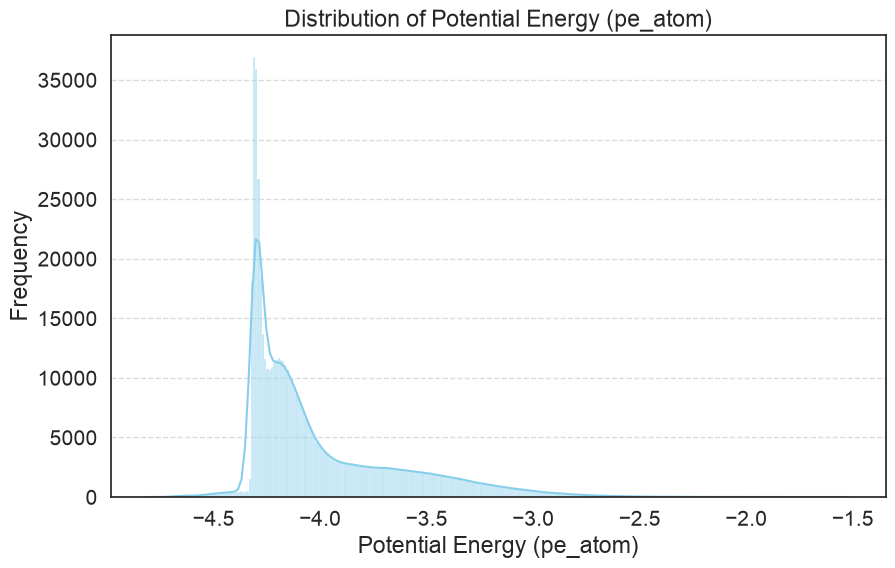

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(silicon_dataset['pe_atom'], kde=True, color='skyblue')
plt.title('Distribution of Potential Energy (pe_atom)')
plt.xlabel('Potential Energy (pe_atom)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [71]:
# Check for missing values in each column
missing_values = silicon_dataset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
timestep    0
box_x       0
box_y       0
box_z       0
atom_id     0
           ..
g2_35       0
g2_36       0
g2_37       0
g2_38       0
g2_39       0
Length: 84, dtype: int64


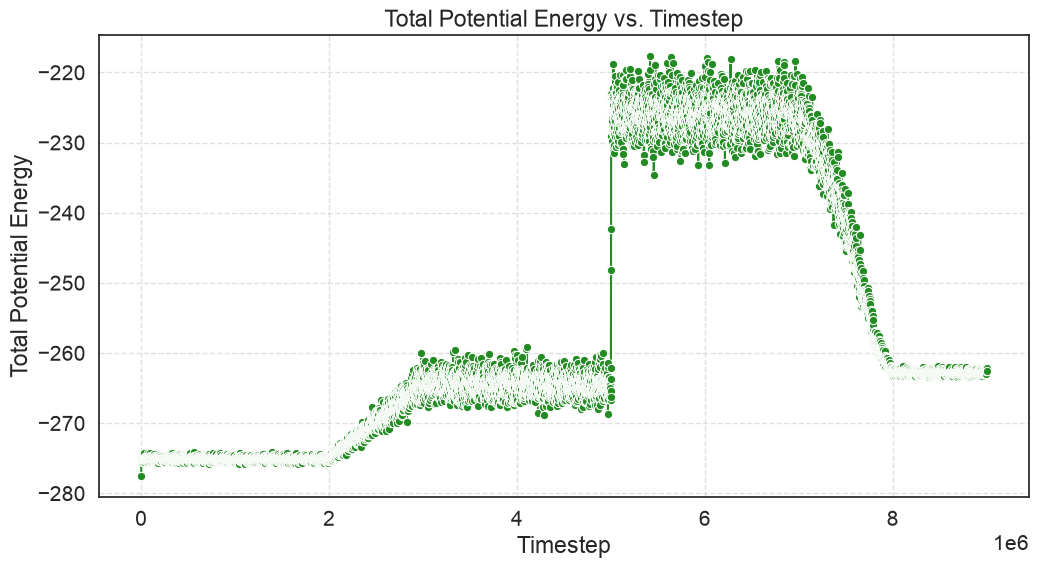

In [72]:
# Group by timestep and sum the potential energy of all atoms to get total energy
total_energy_per_step = silicon_dataset.groupby('timestep')['pe_atom'].sum().reset_index()

# Plot Total Energy vs Timestep
plt.figure(figsize=(12, 6))
sns.lineplot(data=total_energy_per_step, x='timestep', y='pe_atom', marker='o', color='forestgreen')
plt.title('Total Potential Energy vs. Timestep')
plt.xlabel('Timestep')
plt.ylabel('Total Potential Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🫪 **Converting Function**

In [73]:
@njit(parallel=False, fastmath=True)
def compute_symmetry_functions_and_derivatives(coords_3d, eta_rad, Rc, Rs, lmbda, zeta, eta_ang=None, pbc=False, box_lengths=np.zeros(3), combine=False):
    """
    Compute symmetry functions and their derivatives for a set of 3D coordinates.
    """
    num_frames = coords_3d.shape[0]
    num_atoms  = coords_3d.shape[1]

    n_eta_rad = len(eta_rad)
    n_Rs      = len(Rs)
    if eta_ang is None:
        eta_ang = np.copy(eta_rad)
    n_eta_ang = len(eta_ang)
    n_zeta    = len(zeta)
    n_lmbda   = len(lmbda)

    num_radial   = n_eta_rad * n_Rs if combine else n_eta_rad
    num_angular  = n_eta_ang * n_zeta * n_lmbda
    num_sf       = num_radial + num_angular

    fingerprints = np.zeros((num_frames, num_atoms, num_sf), dtype=np.float64)
    dG_dR = np.zeros((num_frames, num_atoms, num_sf, num_atoms, 3), dtype=np.float64)
    
    Lx, Ly, Lz = box_lengths[0], box_lengths[1], box_lengths[2]

    for f in prange(num_frames):
        frame_coords = coords_3d[f]

        for i in range(num_atoms):
            xi, yi, zi = frame_coords[i, 0], frame_coords[i, 1], frame_coords[i, 2]

            for j in range(num_atoms):
                if i == j:
                    continue

                xj, yj, zj = frame_coords[j, 0], frame_coords[j, 1], frame_coords[j, 2]
                dx_ij, dy_ij, dz_ij = xi - xj, yi - yj, zi - zj
                
                if pbc:
                    dx_ij -= Lx * np.round(dx_ij / Lx)
                    dy_ij -= Ly * np.round(dy_ij / Ly)
                    dz_ij -= Lz * np.round(dz_ij / Lz)

                rij = np.sqrt(dx_ij**2 + dy_ij**2 + dz_ij**2)

                if rij > Rc:
                    continue

                cut_ij = 0.5 * (np.cos(np.pi * rij / Rc) + 1.0)
                dfc_ij = -0.5 * (np.pi / Rc) * np.sin(np.pi * rij / Rc)

                inv_rij = 1.0 / rij
                u_ij_x, u_ij_y, u_ij_z = dx_ij * inv_rij, dy_ij * inv_rij, dz_ij * inv_rij

                for e_idx in range(n_eta_rad):
                    eta_r = eta_rad[e_idx]
                    if combine:
                        for p in range(n_Rs):
                            rad_idx = e_idx * n_Rs + p
                            
                            exp_term = np.exp(-eta_r * (rij - Rs[p]) ** 2)
                            fingerprints[f, i, rad_idx] += exp_term * cut_ij
                            
                            dG1_drij = exp_term * dfc_ij + cut_ij * exp_term * (-2.0 * eta_r * (rij - Rs[p]))
                            gx, gy, gz = dG1_drij * u_ij_x, dG1_drij * u_ij_y, dG1_drij * u_ij_z
                            
                            dG_dR[f, i, rad_idx, i, 0] += gx
                            dG_dR[f, i, rad_idx, i, 1] += gy
                            dG_dR[f, i, rad_idx, i, 2] += gz
                            
                            dG_dR[f, i, rad_idx, j, 0] -= gx
                            dG_dR[f, i, rad_idx, j, 1] -= gy
                            dG_dR[f, i, rad_idx, j, 2] -= gz
                    else:
                        rad_idx = e_idx
                        
                        exp_term = np.exp(-eta_rad[e_idx] * (rij - Rs[e_idx]) ** 2)
                        fingerprints[f, i, rad_idx] += exp_term * cut_ij
                        
                        dG1_drij = exp_term * dfc_ij + cut_ij * exp_term * (-2.0 * eta_rad[e_idx] * (rij - Rs[e_idx]))
                        gx, gy, gz = dG1_drij * u_ij_x, dG1_drij * u_ij_y, dG1_drij * u_ij_z
                        
                        dG_dR[f, i, rad_idx, i, 0] += gx
                        dG_dR[f, i, rad_idx, i, 1] += gy
                        dG_dR[f, i, rad_idx, i, 2] += gz
                        
                        dG_dR[f, i, rad_idx, j, 0] -= gx
                        dG_dR[f, i, rad_idx, j, 1] -= gy
                        dG_dR[f, i, rad_idx, j, 2] -= gz

                for k in range(num_atoms):
                    if k == i or k == j:
                        continue

                    xk, yk, zk = frame_coords[k, 0], frame_coords[k, 1], frame_coords[k, 2]
                    dx_ik, dy_ik, dz_ik = xi - xk, yi - yk, zi - zk
                    
                    if pbc:
                        dx_ik -= Lx * np.round(dx_ik / Lx)
                        dy_ik -= Ly * np.round(dy_ik / Ly)
                        dz_ik -= Lz * np.round(dz_ik / Lz)

                    rik = np.sqrt(dx_ik**2 + dy_ik**2 + dz_ik**2)

                    if rik > Rc:
                        continue

                    dx_jk, dy_jk, dz_jk = dx_ik - dx_ij, dy_ik - dy_ij, dz_ik - dz_ij
                    rjk = np.sqrt(dx_jk**2 + dy_jk**2 + dz_jk**2)

                    if rjk > Rc:
                        continue

                    cut_ik = 0.5 * (np.cos(np.pi * rik / Rc) + 1.0)
                    cut_jk = 0.5 * (np.cos(np.pi * rjk / Rc) + 1.0)
                    
                    dfc_ik = -0.5 * (np.pi / Rc) * np.sin(np.pi * rik / Rc)
                    dfc_jk = -0.5 * (np.pi / Rc) * np.sin(np.pi * rjk / Rc)

                    dot_product = dx_ij * dx_ik + dy_ij * dy_ik + dz_ij * dz_ik
                    cos_theta   = dot_product / (rij * rik)
                    r2_sum      = rij ** 2 + rik ** 2 + rjk ** 2

                    inv_rik = 1.0 / rik
                    inv_rjk = 1.0 / rjk
                    u_ik_x, u_ik_y, u_ik_z = dx_ik * inv_rik, dy_ik * inv_rik, dz_ik * inv_rik
                    u_jk_x, u_jk_y, u_jk_z = dx_jk * inv_rjk, dy_jk * inv_rjk, dz_jk * inv_rjk
                    
                    dcos_j_x = -inv_rij * (u_ik_x - cos_theta * u_ij_x)
                    dcos_j_y = -inv_rij * (u_ik_y - cos_theta * u_ij_y)
                    dcos_j_z = -inv_rij * (u_ik_z - cos_theta * u_ij_z)
                    
                    dcos_k_x = -inv_rik * (u_ij_x - cos_theta * u_ik_x)
                    dcos_k_y = -inv_rik * (u_ij_y - cos_theta * u_ik_y)
                    dcos_k_z = -inv_rik * (u_ij_z - cos_theta * u_ik_z)
                    
                    dcos_i_x = -(dcos_j_x + dcos_k_x)
                    dcos_i_y = -(dcos_j_y + dcos_k_y)
                    dcos_i_z = -(dcos_j_z + dcos_k_z)

                    for ea_idx in range(n_eta_ang):
                        exp_term = np.exp(-eta_ang[ea_idx] * r2_sum)
                        B_term = exp_term
                        C_term = cut_ij * cut_ik * cut_jk

                        for z_idx in range(n_zeta):
                            prefactor = 2.0**(1.0 - zeta[z_idx])
                            
                            for l_idx in range(n_lmbda):
                                ang_idx = num_radial + ea_idx * n_zeta * n_lmbda + z_idx * n_lmbda + l_idx
                                
                                A_term = 1.0 + lmbda[l_idx] * cos_theta
                                A_pow = A_term ** zeta[z_idx]
                                A_deriv = zeta[z_idx] * lmbda[l_idx] * (A_term ** max(0.0, zeta[z_idx] - 1.0))
                                
                                fingerprints[f, i, ang_idx] += prefactor * A_pow * B_term * C_term
                                
                                dG2_dcos = prefactor * A_deriv * B_term * C_term
                                
                                dG2_drij = prefactor * A_pow * ( (-2.0 * eta_ang[ea_idx] * rij * B_term) * C_term + B_term * (dfc_ij * cut_ik * cut_jk) )
                                dG2_drik = prefactor * A_pow * ( (-2.0 * eta_ang[ea_idx] * rik * B_term) * C_term + B_term * (cut_ij * dfc_ik * cut_jk) )
                                dG2_drjk = prefactor * A_pow * ( (-2.0 * eta_ang[ea_idx] * rjk * B_term) * C_term + B_term * (cut_ij * cut_ik * dfc_jk) )
                                
                                gx_i = dG2_dcos * dcos_i_x + dG2_drij * u_ij_x + dG2_drik * u_ik_x
                                gy_i = dG2_dcos * dcos_i_y + dG2_drij * u_ij_y + dG2_drik * u_ik_y
                                gz_i = dG2_dcos * dcos_i_z + dG2_drij * u_ij_z + dG2_drik * u_ik_z
                                
                                gx_j = dG2_dcos * dcos_j_x - dG2_drij * u_ij_x + dG2_drjk * u_jk_x
                                gy_j = dG2_dcos * dcos_j_y - dG2_drij * u_ij_y + dG2_drjk * u_jk_y
                                gz_j = dG2_dcos * dcos_j_z - dG2_drij * u_ij_z + dG2_drjk * u_jk_z
                                
                                gx_k = dG2_dcos * dcos_k_x - dG2_drik * u_ik_x - dG2_drjk * u_jk_x
                                gy_k = dG2_dcos * dcos_k_y - dG2_drik * u_ik_y - dG2_drjk * u_jk_y
                                gz_k = dG2_dcos * dcos_k_z - dG2_drik * u_ik_z - dG2_drjk * u_jk_z
                                
                                dG_dR[f, i, ang_idx, i, 0] += gx_i
                                dG_dR[f, i, ang_idx, i, 1] += gy_i
                                dG_dR[f, i, ang_idx, i, 2] += gz_i
                                
                                dG_dR[f, i, ang_idx, j, 0] += gx_j
                                dG_dR[f, i, ang_idx, j, 1] += gy_j
                                dG_dR[f, i, ang_idx, j, 2] += gz_j
                                
                                dG_dR[f, i, ang_idx, k, 0] += gx_k
                                dG_dR[f, i, ang_idx, k, 1] += gy_k
                                dG_dR[f, i, ang_idx, k, 2] += gz_k

    return fingerprints, dG_dR

In [74]:
if generate == True:
    Rc_val = 3.7712  # The exact SW cutoff for Silicon
    

    # # https://arxiv.org/abs/1804.02150 Imbalzano RULE Centered
    # indices_radial = np.array(range(0, N_RADIAL))
    # indices_angular = np.array(range(0, N_ANGULAR / 2))

    # eta_radial = ((N_RADIAL - 1) ** (indices_radial / (N_RADIAL - 1)) / Rc_val) ** 2
    # Rs_grid = np.zeros_like(eta_radial)
    # zeta_grid = np.array([1.0, 4.0, 16.0])
    # eta_angular = (((N_ANGULAR / 2) - 1) ** (indices_angular / ((N_ANGULAR / 2) - 1)) / Rc_val) ** 2
    # lambda_grid = np.array([-1.0, 1.0])


    # # https://arxiv.org/abs/1804.02150 Imbalzano RULE Shifted
    # indices_radial = np.array(range(0, N_RADIAL))
    # indices_angular = np.array(range(0, N_ANGULAR // 2))

    # Rs_grid = Rc_val / N_RADIAL ** (indices_radial / N_RADIAL)
    # eta_radial = np.zeros(N_RADIAL)  # Constant eta value for shifted radial functions
    # for i in range(len(Rs_grid) - 1):
    #     eta_radial[i] = 1.0 / (Rs_grid[i] - Rs_grid[i + 1]) ** 2
    # Rs_grid = np.flip(Rs_grid[1:])
    # eta_radial = np.flip(eta_radial)
    # zeta_grid   = np.array([1.0])
    # eta_angular = (((N_ANGULAR / 2) - 1) ** (indices_angular / ((N_ANGULAR / 2) - 1)) / Rc_val) ** 2
    # lambda_grid = np.array([-1.0, 1.0])


    # # https://arxiv.org/abs/1712.05861 Gastegger RULE Centered
    r_low = 2.0
    r_upp = 3.5
    # grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
    # dr_radial = (r_upp - r_low) / (N_RADIAL - 1)
    # grid_angular = np.linspace(r_low, r_upp, int(N_ANGULAR / 2))
    # dr_angular = (r_upp - r_low) / ((N_ANGULAR / 2) - 1)

    # Rs_grid = np.zeros(N_RADIAL)
    # eta_radial = 1.0 / (grid_radial ** 2) # Inverse square of the grid points for eta values
    # Angular symmetry function parameters
    eta_angular = np.array([0.001, 0.01, 0.05, 0.1])                     # Gentle decay for triplets
    lambda_grid = np.array([-1.0, 1.0])                 # Anchors at 0 and 180 degrees
    zeta_grid   = np.array([1.0, 2.0, 4.0, 8.0, 16.0])  # Resolution from broad to sharp
    

    # https://arxiv.org/abs/1712.05861 Gastegger RULE Shifted
    # r_low = 0.5
    # r_upp = Rc_val - 0.5
    grid_radial = np.linspace(r_low, r_upp, N_RADIAL)
    dr_radial = (r_upp - r_low) / (N_RADIAL - 1)
    # grid_angular = np.linspace(r_low, r_upp, int(N_ANGULAR / 2))
    # dr_angular = (r_upp - r_low) / ((int(N_ANGULAR / 2) - 1))

    Rs_grid = grid_radial
    eta_radial = np.full(N_RADIAL, 1.0 / (2.0 * dr_radial**2))  # Constant eta value for shifted radial functions
    # zeta_grid   = np.array([1.0])
    # eta_angular = np.full(N_ANGULAR / 2, 1.0 / (2.0 * dr_angular**2))  # Constant eta value for shifted angular functions
    # lambda_grid = np.array([-1.0, 1.0])

    atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))
    coords_flat = silicon_dataset[['x', 'y', 'z']].values
    coords_3d = coords_flat.reshape(-1, atoms_per_frame, 3)
    n_frames = coords_3d.shape[0]

    num_radial  = len(eta_radial) 
    num_angular = len(eta_angular) * len(zeta_grid) * len(lambda_grid)
    num_sf      = num_radial + num_angular

    print(f"Found {n_frames} frames of {atoms_per_frame} atoms each.")
    print(f"Symmetry functions: {num_radial} radial + {num_angular} angular = {num_sf} total")

    batch_size = 1
    risultati_list = []
    
    # --- LA MODIFICA SALVA-RAM ---
    # Definiamo la forma esatta dell'array finale delle derivate
    dG_dR_shape = (n_frames, atoms_per_frame, num_sf, atoms_per_frame, 3)
    
    # Creiamo un file su disco che si comporta come un array NumPy (mmap)
    # Usiamo float32 per dimezzare lo spazio occupato
    dG_dR_mmap = np.memmap('dG_dR_dataset.npy', dtype='float32', mode='w+', shape=dG_dR_shape)
    # -----------------------------

    box_lengths = np.array([
        silicon_dataset['box_x'].iloc[0],
        silicon_dataset['box_y'].iloc[0],
        silicon_dataset['box_z'].iloc[0]
    ])

    for i in tqdm(range(0, n_frames, batch_size), desc="Computing SFs and derivatives"):
        batch_coords = coords_3d[i : i + batch_size]
        
        batch_res, batch_dG_dR = compute_symmetry_functions_and_derivatives(
            coords_3d=batch_coords,
            Rc=Rc_val,
            eta_rad=eta_radial,
            Rs=Rs_grid,
            zeta=zeta_grid,
            eta_ang=eta_angular,
            lmbda=lambda_grid,
            pbc=True,
            box_lengths=box_lengths
        )
        
        # Le fingerprints sono piccole, possiamo tenerle in lista
        risultati_list.append(batch_res)
        
        # I gradienti sono enormi: li scriviamo DIRETTAMENTE su disco (convertiti a float32)
        dG_dR_mmap[i : i + batch_size] = batch_dG_dR.astype(np.float32)

    # Chiudiamo e salviamo definitivamente il file su disco
    dG_dR_mmap.flush()
    print(f"Derivatives safely written to disk! File shape: {dG_dR_shape}")

    # Il resto del codice per le G1 e G2 rimane invariato
    risultati_3d = np.vstack(risultati_list)
    print("Computation completed! Formatting the dataframe...")

    num_symmetry_functions = risultati_3d.shape[2]
    symmetry_flat = risultati_3d.reshape(-1, num_symmetry_functions)

    symmetry_cols = [f'sf_{i}' for i in range(num_symmetry_functions)]
    symmetry_df   = pd.DataFrame(symmetry_flat, columns=symmetry_cols)

    g1_cols = symmetry_cols[:num_radial]
    g2_cols = symmetry_cols[num_radial:]
    g1_df   = symmetry_df[g1_cols].copy()
    g2_df   = symmetry_df[g2_cols].copy()
    g1_df.columns = [f'g1_{i}' for i in range(len(g1_df.columns))]
    g2_df.columns = [f'g2_{i}' for i in range(len(g2_df.columns))]

    silicon_dataset = pd.concat([silicon_dataset.reset_index(drop=True), g1_df, g2_df], axis=1)

    print(f"Symmetry functions added! G1:{g1_df.shape[1]} G2:{g2_df.shape[1]} Dataset shape: {silicon_dataset.shape}")
    silicon_dataset.to_csv(symmetry_dataset_path, index=False)

## 🔄 **Data Preprocessing**

In [75]:
n_atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))
symmetry_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]

print("=== DATASET DIAGNOSTICS ===")
print(f"Frames totali: {silicon_dataset['timestep'].nunique()}")
print(f"Atomi per frame: {n_atoms_per_frame}")
print(f"Features: {len(symmetry_cols)} symmetry functions")
print(f"\npe_atom statistics:")
print(silicon_dataset['pe_atom'].describe())
print(f"\nRange pe_atom: {silicon_dataset['pe_atom'].max() - silicon_dataset['pe_atom'].min():.4f} eV")

# Check symmetry functions are not all zero or degenerate
sf_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]
sf_data = silicon_dataset[sf_cols]
print(f"\nSymmetry function statistics:")
std_threshold = 1e-10
low_std_cols = silicon_dataset[symmetry_cols].std().loc[lambda s: s < std_threshold].index.tolist()

print(f"Columns with zero variance: {(sf_data.std() < 1e-10).sum()}, {low_std_cols}")
print(f"Columns with NaN: {sf_data.isna().sum().sum()}")
print(f"Mean of all SF values: {sf_data.values.mean():.4f}")
print(f"Std of all SF values:  {sf_data.values.std():.4f}")

# std_threshold = 1e-10

# # Trova le colonne a bassa deviazione standard
# low_std_cols = silicon_dataset[symmetry_cols].std().loc[lambda s: s < std_threshold].index.tolist()

# print(f"Rimozione colonne con std < {std_threshold}: {low_std_cols}")
# silicon_dataset = silicon_dataset.drop(columns=low_std_cols)

=== DATASET DIAGNOSTICS ===
Frames totali: 9001
Atomi per frame: 64
Features: 72 symmetry functions

pe_atom statistics:
count    576064.000000
mean         -4.004276
std           0.359242
min          -4.817480
25%          -4.275050
50%          -4.142860
75%          -3.838490
max          -1.510620
Name: pe_atom, dtype: float64

Range pe_atom: 3.3069 eV

Symmetry function statistics:
Columns with zero variance: 0, []
Columns with NaN: 0
Mean of all SF values: 0.0454
Std of all SF values:  0.1378


In [76]:
n_atoms = np.unique(silicon_dataset['atom_id']).size

silicon_dataset['frame_id'] = np.repeat(np.arange(len(silicon_dataset) // n_atoms), n_atoms)

all_frames = silicon_dataset['frame_id'].unique()
train_frames, temp_frames = train_test_split(all_frames, test_size=0.10, random_state=SEED)
val_frames, test_frames = train_test_split(temp_frames, test_size=0.50, random_state=SEED)

train_df = silicon_dataset[silicon_dataset['frame_id'].isin(train_frames)].sort_values(['frame_id', 'atom_id'])
val_df = silicon_dataset[silicon_dataset['frame_id'].isin(val_frames)].sort_values(['frame_id', 'atom_id'])
test_df = silicon_dataset[silicon_dataset['frame_id'].isin(test_frames)].sort_values(['frame_id', 'atom_id'])

symmetry_cols = [c for c in silicon_dataset.columns if c.startswith('g1_') or c.startswith('g2_')]

X_train_flat = train_df[symmetry_cols].values
X_val_flat = val_df[symmetry_cols].values
X_test_flat = test_df[symmetry_cols].values

y_train_total = train_df.groupby('frame_id')['pe_atom'].sum().values
y_val_total = val_df.groupby('frame_id')['pe_atom'].sum().values
y_test_total = test_df.groupby('frame_id')['pe_atom'].sum().values

F_train_flat = train_df[['fx', 'fy', 'fz']].values
F_val_flat = val_df[['fx', 'fy', 'fz']].values
F_test_flat = test_df[['fx', 'fy', 'fz']].values

feature_scaler = StandardScaler()
feature_scaler.fit(X_train_flat)
feature_scaler.scale_[feature_scaler.scale_ < 1e-2] = 1.0

X_train_scaled_flat = feature_scaler.transform(X_train_flat)
X_val_scaled_flat = feature_scaler.transform(X_val_flat)
X_test_scaled_flat = feature_scaler.transform(X_test_flat)

num_features = X_train_flat.shape[1]

X_train_scaled = X_train_scaled_flat.reshape(-1, n_atoms, num_features)
X_val_scaled = X_val_scaled_flat.reshape(-1, n_atoms, num_features)
X_test_scaled = X_test_scaled_flat.reshape(-1, n_atoms, num_features)

F_train = F_train_flat.reshape(-1, n_atoms, 3)
F_val = F_val_flat.reshape(-1, n_atoms, 3)
F_test = F_test_flat.reshape(-1, n_atoms, 3)

mean_total_energy = y_train_total.mean()
y_train_shifted = y_train_total - mean_total_energy
y_val_shifted = y_val_total - mean_total_energy
y_test_shifted = y_test_total - mean_total_energy

print(f"Shapes -> X_train: {X_train_scaled.shape}, y_train: {y_train_shifted.shape}")
print(f"Shapes -> F_train: {F_train.shape}")

Shapes -> X_train: (8100, 64, 72), y_train: (8100,)
Shapes -> F_train: (8100, 64, 3)


In [77]:
import torch
from torch.utils.data import Dataset
import numpy as np

class LazyHDNNPDataset(Dataset):
    def __init__(self, G_data, dG_dR_path, E_data, F_data, original_indices, sigma_scaler, dG_dR_shape):
        self.G = torch.tensor(G_data, dtype=torch.float32)
        self.E = torch.tensor(E_data, dtype=torch.float32)
        self.F = torch.tensor(F_data, dtype=torch.float32)
        
        self.indices = original_indices
        
        # LA SOLUZIONE: Usiamo np.memmap invece di np.load per i file binari puri.
        # Passiamo mode='r' (read-only) e gli diciamo la forma esatta del file.
        self.dG_dR_mmap = np.memmap(dG_dR_path, dtype='float32', mode='r', shape=dG_dR_shape)
        
        self.sigma = torch.tensor(sigma_scaler, dtype=torch.float32).view(1, -1, 1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        
        # Legge dal disco solo questo specifico frame
        dG_dR_frame = torch.tensor(np.array(self.dG_dR_mmap[real_idx]), dtype=torch.float32)
        dG_dR_frame_scaled = dG_dR_frame / self.sigma
        
        return self.G[idx], dG_dR_frame_scaled, self.E[idx], self.F[idx]

# --- CREAZIONE DEI DATASET ---

sigma_scaler = feature_scaler.scale_
dataset_path = 'dG_dR_dataset.npy'

# Dobbiamo ricostruire la forma totale del file salvato per dire a memmap come leggerlo
n_frames_total = len(all_frames)
dG_dR_shape = (n_frames_total, n_atoms, num_features, n_atoms, 3)

train_ds = LazyHDNNPDataset(X_train_scaled, dataset_path, y_train_shifted, F_train, train_frames, sigma_scaler, dG_dR_shape)
val_ds   = LazyHDNNPDataset(X_val_scaled, dataset_path, y_val_shifted, F_val, val_frames, sigma_scaler, dG_dR_shape)
test_ds  = LazyHDNNPDataset(X_test_scaled, dataset_path, y_test_shifted, F_test, test_frames, sigma_scaler, dG_dR_shape)

print(f"Train dataset length: {len(train_ds)} frames")
print(f"Validation dataset length: {len(val_ds)} frames")
print(f"Test dataset length: {len(test_ds)} frames")

Train dataset length: 8100 frames
Validation dataset length: 450 frames
Test dataset length: 451 frames


In [78]:
from torch.utils.data import DataLoader

def make_loader(ds, batch_size, shuffle, drop_last):
    # Dato che i tensori sono già caricati integralmente in RAM, 
    # num_workers > 0 creerebbe solo overhead e spreco di memoria.
    if device.type == "cuda":
        return DataLoader(
            ds, 
            batch_size=batch_size, 
            shuffle=shuffle, 
            drop_last=drop_last,
            num_workers=0, 
            pin_memory=True  # Fondamentale per Nvidia: accelera il trasferimento CPU -> GPU
        )
    else:  # mps (Mac) o cpu
        return DataLoader(
            ds, 
            batch_size=batch_size, 
            shuffle=shuffle, 
            drop_last=drop_last,
            num_workers=0, 
            pin_memory=False
        )

# Creazione dei data loaders (il resto rimane invariato)
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [79]:
input_features = X_train_scaled.shape[2] 
output_features = 1 

print(f"Input features per atom: {input_features}")
print(f"Output features: {output_features}")

for G_batch, dG_dR_batch, E_batch, F_batch in train_loader:
    print("Features (G) batch shape:        ", G_batch.shape)
    print("Derivatives (dG_dR) batch shape: ", dG_dR_batch.shape)
    print("Energies (E) batch shape:        ", E_batch.shape)
    print("Forces (F) batch shape:          ", F_batch.shape)
    break

Input features per atom: 72
Output features: 1


Features (G) batch shape:         torch.Size([128, 64, 72])
Derivatives (dG_dR) batch shape:  torch.Size([128, 64, 72, 64, 3])
Energies (E) batch shape:         torch.Size([128])
Forces (F) batch shape:           torch.Size([128, 64, 3])


## 🛠️ **Model Building**

In [80]:
import torch
import torch.nn as nn

class FeedForwardNet(nn.Module):
    def __init__(self, in_features, out_features=1, hidden_layers=3, hidden_size=128):
        super().__init__()
        
        # Inizializziamo i layer
        modules = [nn.Linear(in_features, hidden_size), nn.GELU()]
        for _ in range(hidden_layers - 1):
            modules.append(nn.Linear(hidden_size, hidden_size))
            modules.append(nn.GELU())
        
        modules.append(nn.Linear(hidden_size, out_features))
        self.atomic_net = nn.Sequential(*modules).float()
        
        # Inizializzazione personalizzata dei pesi (Cruciale per le forze)
        self._init_weights()

    def _init_weights(self):
        for m in self.atomic_net:
            if isinstance(m, nn.Linear):
                # Inizializza i pesi piccoli per evitare forze esplosive alla prima epoca
                nn.init.xavier_normal_(m.weight, gain=0.1)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # 0. Forza l'input in float32 esplicito
        out = x.to(torch.float32)
        
        # 1. Iteriamo manualmente sui layer per avere controllo totale
        # invece di usare self.atomic_net(out)
        for layer in self.atomic_net:
            out = layer(out)
        
        # 2. Rimuove l'ultima dimensione inutile (batch, atoms, 1) -> (batch, atoms)
        atomic_energies = out.squeeze(-1)
        
        # 3. Somma per l'energia totale della molecola/frame
        total_energy = torch.sum(atomic_energies, dim=1)
        
        return total_energy

In [81]:
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter
# Assicurati di aver importato summary (es. from torchinfo import summary)

# 1. Inizializza il modello (usiamo in_features=num_features che abbiamo definito prima)
model = FeedForwardNet(in_features=num_features, hidden_layers=HIDDEN_LAYERS, hidden_size=HIDDEN_SIZE).to(device)

# 2. Stringa del nome esperimento (Senza dropout)
experiment_name = f"experiment_hl{HIDDEN_LAYERS}_hs{HIDDEN_SIZE}_bs{BATCH_SIZE}_lr{LEARNING_RATE}_ep{EPOCHS}_pt{PATIENCE}_l2{L2_LAMBDA}".replace('.', 'p')
timestamp = datetime.now().strftime("%m%d-%H%M")
experiment_name = f"{experiment_name}_{timestamp}"
print(f"Experiment name: {experiment_name}")

# 3. Grafo su TensorBoard (Tensore 3D: [batch=1, atomi, features])
writer = SummaryWriter(f"./{logs_dir}/{experiment_name}")
x_dummy = torch.randn(1, n_atoms, num_features).to(device)
writer.add_graph(model, x_dummy)
writer.close()

# 4. Summary su CPU / GPU
if device.type != "cuda":
    # Su MPS o CPU
    summary(model.to("cpu"), input_size=(n_atoms, num_features))
    model = model.to(device)

    # Rimuovi tutti gli hook rimasti da torchsummary
    for module in model.modules():
        module._forward_hooks.clear()
        module._backward_hooks.clear()

if device.type == "cuda":
    # torch.compile(model) # Tienilo commentato per ora, con le forze autograd a volte dà noie
    summary(model, input_size=(n_atoms, num_features))

Experiment name: experiment_hl2_hs64_bs128_lr0p0001_ep1500_pt75_l20p0_0703-1554
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 64, 64]           4,672
              GELU-2               [-1, 64, 64]               0
            Linear-3               [-1, 64, 64]           4,160
              GELU-4               [-1, 64, 64]               0
            Linear-5                [-1, 64, 1]              65
Total params: 8,897
Trainable params: 8,897
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.13
Params size (MB): 0.03
Estimated Total Size (MB): 0.18
----------------------------------------------------------------


In [82]:
writer = SummaryWriter(f"./{logs_dir}/{experiment_name}")

# LA MODIFICA: Il tensore fittizio ora è 3D -> (batch_size=1, n_atoms, input_features)
x = torch.randn(1, n_atoms, input_features).to(device)

writer.add_graph(model, x)
writer.close()

In [83]:
# model = torch.compile(model)

## 🧮 **Network Parameters**

In [84]:
# 1. Iperparametro fondamentale: Peso della Loss sulle Forze
# Spesso si parte con valori molto alti (es. 100 o 1000) per costringere 
# la rete a imparare prima le derivate (geometria) e poi l'energia assoluta.
FORCE_WEIGHT = 100.0  

# 2. Set up loss function (La useremo due volte nel loop: per E e per F)
criterion = nn.MSELoss()

# 3. AdamW is perfect here. weight_decay acts as our regularizer instead of Dropout.
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# 4. Scheduler: ReduceLROnPlateau is excellent for HDNNPs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-6
)   

# 5. DISATTIVATO: Mixed Precision Training. 
# Motivo: Il calcolo analitico delle forze (torch.autograd.grad) in float16 
# genera severi problemi di instabilità numerica (underflow/NaN). 
# Per i potenziali neurali è tassativo mantenere il puro float32.
# scaler = torch.amp.GradScaler(...) # <-- Rimosso per sicurezza

## 🧠 **Model Training**

In [85]:
# Initialize best model tracking variables
best_model = None
best_performance = float('inf')

In [86]:
# def train_one_epoch(model, train_loader, criterion, optimizer, device, force_weight=100.0):
#     """
#     Perform one training epoch calculating analytical forces via autograd.
#     """
#     model.train()

#     running_loss = 0.0
#     all_E_preds, all_E_targets = [], []
#     all_F_preds, all_F_targets = [], []

#     for G_batch, dG_dR_batch, E_targets, F_targets in train_loader:
#         G_batch = G_batch.to(device)
#         dG_dR_batch = dG_dR_batch.to(device)
#         E_targets = E_targets.to(device)
#         F_targets = F_targets.to(device)

#         optimizer.zero_grad(set_to_none=True)

#         # Autograd needs to track operations on the input to compute forces
#         G_batch.requires_grad_(True)

#         # 1. Predict Energy
#         E_preds = model(G_batch)
        
#         # 2. Compute derivatives of Energy wrt Symmetry Functions
#         dE_dG = torch.autograd.grad(
#             outputs=E_preds,
#             inputs=G_batch,
#             grad_outputs=torch.ones_like(E_preds),
#             create_graph=True,  # Mandatory in train loop to backprop the force error
#             retain_graph=True
#         )[0]

#         # 3. Chain Rule via Einstein Summation to get spatial forces
#         F_preds = -torch.einsum('bim, bimja -> bja', dE_dG, dG_dR_batch)

#         # 4. Calculate Combined Loss
#         loss_E = criterion(E_preds.squeeze(), E_targets)
#         loss_F = criterion(F_preds, F_targets)
#         loss = loss_E + force_weight * loss_F

#         # 5. Backpropagation step
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()

#         running_loss += loss.item() * G_batch.size(0)
        
#         all_E_preds.append(E_preds.detach().cpu().numpy())
#         all_E_targets.append(E_targets.cpu().numpy())
#         all_F_preds.append(F_preds.detach().cpu().numpy())
#         all_F_targets.append(F_targets.cpu().numpy())

#     epoch_loss = running_loss / len(train_loader.dataset)
    
#     # Calculate Energy RMSE
#     E_targets_flat = np.concatenate(all_E_targets).flatten()
#     E_preds_flat = np.concatenate(all_E_preds).flatten()
#     rmse_E = np.sqrt(mean_squared_error(E_targets_flat, E_preds_flat))
    
#     # Calculate Force RMSE
#     F_targets_flat = np.concatenate(all_F_targets).flatten()
#     F_preds_flat = np.concatenate(all_F_preds).flatten()
#     rmse_F = np.sqrt(mean_squared_error(F_targets_flat, F_preds_flat))

#     return epoch_loss, rmse_E, rmse_F

In [87]:
# def validate_one_epoch(model, val_loader, criterion, device, force_weight=100.0):
#     """
#     Perform one validation epoch. 
#     Notice the ABSENCE of torch.no_grad() because autograd is needed for forces.
#     """
#     model.eval()

#     running_loss = 0.0
#     all_E_preds, all_E_targets = [], []
#     all_F_preds, all_F_targets = [], []

#     for G_batch, dG_dR_batch, E_targets, F_targets in val_loader:
#         G_batch = G_batch.to(device)
#         dG_dR_batch = dG_dR_batch.to(device)
#         E_targets = E_targets.to(device)
#         F_targets = F_targets.to(device)

#         G_batch.requires_grad_(True)

#         E_preds = model(G_batch)
        
#         # create_graph=False saves memory since we don't backprop in validation
#         dE_dG = torch.autograd.grad(
#             outputs=E_preds,
#             inputs=G_batch,
#             grad_outputs=torch.ones_like(E_preds),
#             create_graph=False, 
#             retain_graph=False
#         )[0]

#         F_preds = -torch.einsum('bim, bimja -> bja', dE_dG, dG_dR_batch)

#         loss_E = criterion(E_preds.squeeze(), E_targets)
#         loss_F = criterion(F_preds, F_targets)
#         loss = loss_E + force_weight * loss_F

#         running_loss += loss.item() * G_batch.size(0)
        
#         all_E_preds.append(E_preds.detach().cpu().numpy())
#         all_E_targets.append(E_targets.cpu().numpy())
#         all_F_preds.append(F_preds.detach().cpu().numpy())
#         all_F_targets.append(F_targets.cpu().numpy())

#     epoch_loss = running_loss / len(val_loader.dataset)
    
#     E_targets_flat = np.concatenate(all_E_targets).flatten()
#     E_preds_flat = np.concatenate(all_E_preds).flatten()
#     rmse_E = np.sqrt(mean_squared_error(E_targets_flat, E_preds_flat))
    
#     F_targets_flat = np.concatenate(all_F_targets).flatten()
#     F_preds_flat = np.concatenate(all_F_preds).flatten()
#     rmse_F = np.sqrt(mean_squared_error(F_targets_flat, F_preds_flat))

#     return epoch_loss, rmse_E, rmse_F

In [88]:
import numpy as np
import torch
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm # Aggiunge la barra di progresso nei notebook!

def train_one_epoch(model, train_loader, criterion, optimizer, device, force_weight=100.0):
    model.train()

    running_loss = 0.0
    all_E_preds, all_E_targets = [], []
    all_F_preds, all_F_targets = [], []

    # Creiamo la barra di progresso per i batch
    pbar = tqdm(train_loader, desc="Training Batches", leave=False)

    for G_batch, dG_dR_batch, E_targets, F_targets in pbar:
        G_batch = G_batch.to(device)
        dG_dR_batch = dG_dR_batch.to(device)
        E_targets = E_targets.to(device)
        F_targets = F_targets.to(device)

        # 1. CONTROLLO SICUREZZA DATI (Verifica se NumPy ha salvato errori)
        if torch.isnan(dG_dR_batch).any():
            print("\n[!] ERRORE FATALE: Il tensore delle derivate (dG_dR) contiene NaN dal disco!")
            return float('nan'), float('nan'), float('nan')

        optimizer.zero_grad(set_to_none=True)
        G_batch.requires_grad_(True)

        E_preds = model(G_batch)

        dE_dG = torch.autograd.grad(
            outputs=E_preds,
            inputs=G_batch,
            grad_outputs=torch.ones_like(E_preds),
            create_graph=True,
            retain_graph=True
        )[0]

        F_preds = -torch.einsum('bim, bimja -> bja', dE_dG, dG_dR_batch)

        # 2. CONTROLLO SICUREZZA RETE (Verifica se i gradienti sono esplosi)
        if torch.isnan(E_preds).any() or torch.isnan(F_preds).any():
            print("\n[!] ERRORE FATALE: La rete ha previsto NaN! I gradienti sono esplosi nel batch.")
            return float('nan'), float('nan'), float('nan')

        loss_E = criterion(E_preds.squeeze(), E_targets)
        loss_F = criterion(F_preds, F_targets)
        loss = loss_E + force_weight * loss_F

        loss.backward()

        # 3. FRENO D'EMERGENZA: Abbassato da 1.0 a 0.1 per frenare i salti di Adam
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
        optimizer.step()

        running_loss += loss.item() * G_batch.size(0)

        all_E_preds.append(E_preds.detach().cpu().numpy())
        all_E_targets.append(E_targets.cpu().numpy())
        all_F_preds.append(F_preds.detach().cpu().numpy())
        all_F_targets.append(F_targets.cpu().numpy())

        # Aggiorna la barra stampando le loss in tempo reale
        pbar.set_postfix({'L_E': f"{loss_E.item():.2f}", 'L_F': f"{loss_F.item():.2f}"})

    epoch_loss = running_loss / len(train_loader.dataset)
    
    E_targets_flat = np.concatenate(all_E_targets).flatten()
    E_preds_flat = np.concatenate(all_E_preds).flatten()
    rmse_E = np.sqrt(mean_squared_error(E_targets_flat, E_preds_flat))
    
    F_targets_flat = np.concatenate(all_F_targets).flatten()
    F_preds_flat = np.concatenate(all_F_preds).flatten()
    rmse_F = np.sqrt(mean_squared_error(F_targets_flat, F_preds_flat))

    return epoch_loss, rmse_E, rmse_F


def validate_one_epoch(model, val_loader, criterion, device, force_weight=100.0):
    model.eval()

    running_loss = 0.0
    all_E_preds, all_E_targets = [], []
    all_F_preds, all_F_targets = [], []

    pbar = tqdm(val_loader, desc="Validation Batches", leave=False)

    for G_batch, dG_dR_batch, E_targets, F_targets in pbar:
        G_batch = G_batch.to(device)
        dG_dR_batch = dG_dR_batch.to(device)
        E_targets = E_targets.to(device)
        F_targets = F_targets.to(device)

        G_batch.requires_grad_(True)

        E_preds = model(G_batch)
        
        dE_dG = torch.autograd.grad(
            outputs=E_preds,
            inputs=G_batch,
            grad_outputs=torch.ones_like(E_preds),
            create_graph=False, 
            retain_graph=False
        )[0]

        F_preds = -torch.einsum('bim, bimja -> bja', dE_dG, dG_dR_batch)

        loss_E = criterion(E_preds.squeeze(), E_targets)
        loss_F = criterion(F_preds, F_targets)
        loss = loss_E + force_weight * loss_F

        running_loss += loss.item() * G_batch.size(0)
        
        all_E_preds.append(E_preds.detach().cpu().numpy())
        all_E_targets.append(E_targets.cpu().numpy())
        all_F_preds.append(F_preds.detach().cpu().numpy())
        all_F_targets.append(F_targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    
    E_targets_flat = np.concatenate(all_E_targets).flatten()
    E_preds_flat = np.concatenate(all_E_preds).flatten()
    rmse_E = np.sqrt(mean_squared_error(E_targets_flat, E_preds_flat))
    
    F_targets_flat = np.concatenate(all_F_targets).flatten()
    F_preds_flat = np.concatenate(all_F_preds).flatten()
    rmse_F = np.sqrt(mean_squared_error(F_targets_flat, F_preds_flat))

    return epoch_loss, rmse_E, rmse_F

In [89]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, device,
        patience=0, evaluation_metric="val_loss", mode='min',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", 
        force_weight=100.0):
    """
    Train the neural network model evaluating both Energy and Forces.
    """

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_rmse_E': [], 'val_rmse_E': [],
        'train_rmse_F': [], 'val_rmse_F': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    best_val_loss_print = float('inf')

    for epoch in range(1, epochs + 1):

        train_loss, train_rmse_E, train_rmse_F = train_one_epoch(
            model, train_loader, criterion, optimizer, device, force_weight
        )

        val_loss, val_rmse_E, val_rmse_F = validate_one_epoch(
            model, val_loader, criterion, device, force_weight
        )

        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        elif isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
            scheduler.step()

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_rmse_E'].append(train_rmse_E)
        training_history['val_rmse_E'].append(val_rmse_E)
        training_history['train_rmse_F'].append(train_rmse_F)
        training_history['val_rmse_F'].append(val_rmse_F)

        if writer is not None:
            writer.add_scalars('Loss', {'Train': train_loss, 'Val': val_loss}, epoch)
            writer.add_scalars('RMSE_Energy', {'Train': train_rmse_E, 'Val': val_rmse_E}, epoch)
            writer.add_scalars('RMSE_Force', {'Train': train_rmse_F, 'Val': val_rmse_F}, epoch)

        is_val_improvement = False
        if val_loss < best_val_loss_print:
            best_val_loss_print = val_loss
            is_val_improvement = True

        should_print = False
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            should_print = True
        elif verbose == -1 and is_val_improvement:
            should_print = True
        elif verbose < -1 and (epoch % abs(verbose) == 0 or is_val_improvement):
            should_print = True

        if should_print:
            print(f"Ep {epoch:3d}/{epochs} | "
                  f"Loss: T={train_loss:.3e} V={val_loss:.3e} | "
                  f"RMSE_E: T={train_rmse_E:.4f} V={val_rmse_E:.4f} | "
                  f"RMSE_F: T={train_rmse_F:.4f} V={val_rmse_F:.4f}")

        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), f"./models/{experiment_name}_model.pt")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load(f"./models/{experiment_name}_model.pt"))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")
    elif patience == 0:
        torch.save(model.state_dict(), f"./models/{experiment_name}_model.pt")

    if writer is not None:
        writer.close()

    return model, training_history

In [ ]:
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    writer=writer,
    verbose=-10,
    experiment_name=experiment_name
)

if training_history['val_loss'][-1] < best_performance:
    best_model = model
    best_performance = training_history['val_loss'][-1]

Avvio addestramento con rete pulita e WARMUP attivo...
Training 1500 epochs...



[!] ERRORE FATALE: La rete ha previsto NaN! I gradienti sono esplosi nel batch.


ValueError: Input contains NaN.

In [ ]:
# Analisi estrema dei dati
print(f"X_train_scaled range: {X_train_scaled.min():.2f} / {X_train_scaled.max():.2f}")
print(f"y_train_shifted range: {y_train_shifted.min():.2f} / {y_train_shifted.max():.2f}")

# Caccia al valore inf o nan
if not np.isfinite(X_train_scaled).all():
    print("ERRORE: X_train_scaled contiene valori non finiti (inf o nan)!")
if not np.isfinite(y_train_shifted).all():
    print("ERRORE: y_train_shifted contiene valori non finiti (inf o nan)!")

# Controllo se la media è esplosa
if np.abs(y_train_shifted.mean()) > 1e5:
    print("ATTENZIONE: La media dell'energia è sospettosamente alta. Controlla le unità di misura!")

X_train_scaled range: -1.72 / 47.51
y_train_shifted range: -21.23 / 38.65


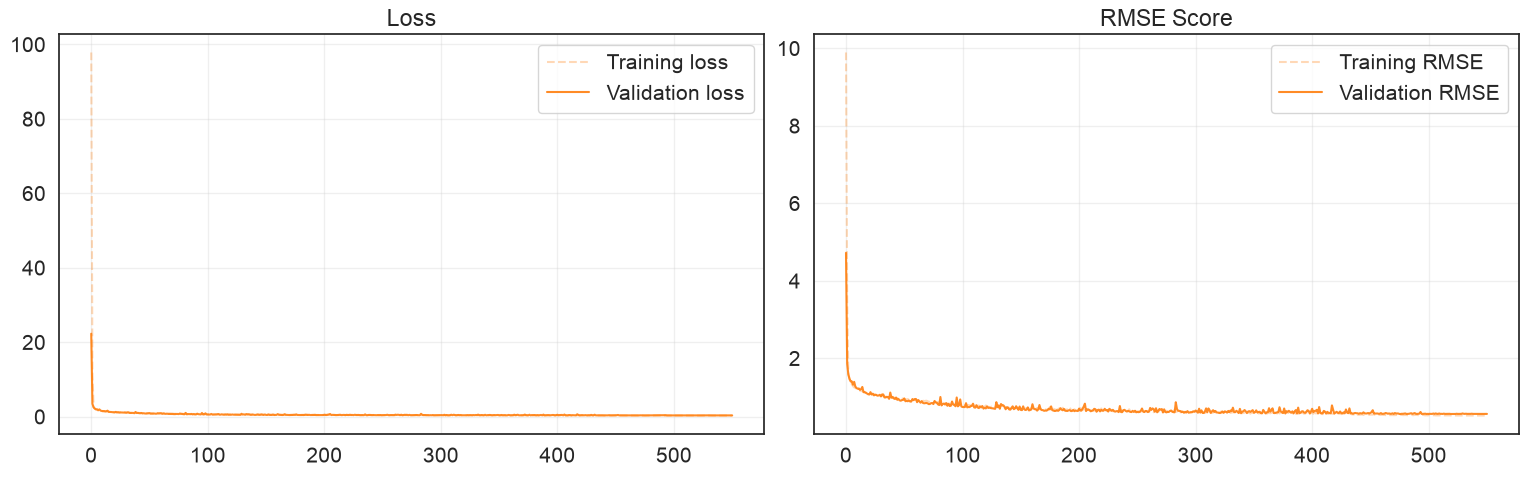

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_rmse'], label='Training RMSE', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_rmse'], label='Validation RMSE', alpha=0.9, color='#ff7f0e')
ax2.set_title('RMSE Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Mean Absolute Error (MAE): 0.3371
Root Mean Squared Error (RMSE):  0.5586
R-squared (R2) Score:      0.9992


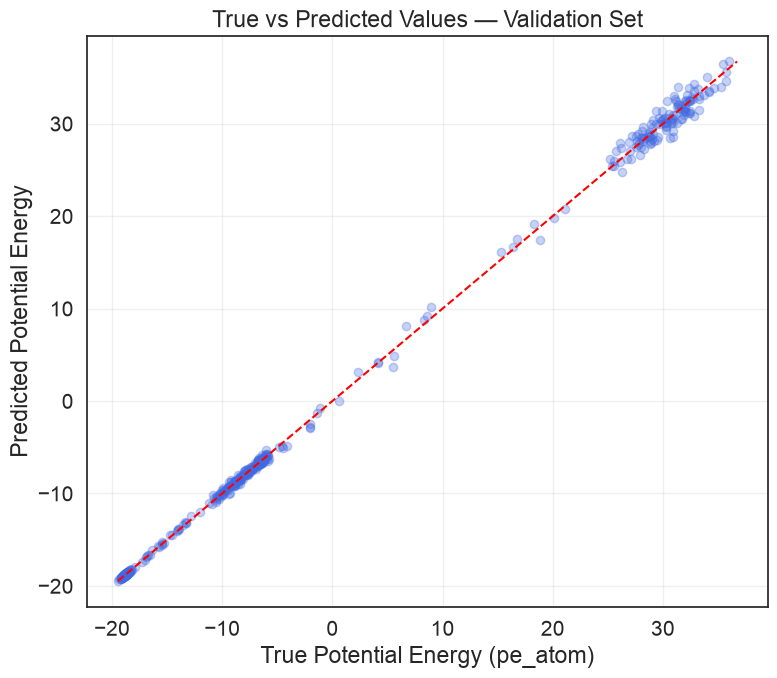

In [ ]:
# @title Evaluate Regression Performance
val_preds, val_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)

        val_preds.append(logits.cpu().numpy())
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds, axis=0)
val_targets = np.concatenate(val_targets, axis=0)

# Calculate overall validation metrics
val_mae = mean_absolute_error(val_targets, val_preds)
val_mse = np.sqrt(mean_squared_error(val_targets, val_preds))
val_r2 = r2_score(val_targets, val_preds)

print(f"Mean Absolute Error (MAE): {val_mae:.4f}")
print(f"Root Mean Squared Error (RMSE):  {val_mse:.4f}")
print(f"R-squared (R2) Score:      {val_r2:.4f}")

# Generate Scatter Plot: True vs Predicted
plt.figure(figsize=(8, 7))
plt.scatter(val_targets, val_preds, alpha=0.3, color='royalblue')

# Plot the ideal prediction line (y = x)
min_val = min(val_targets.min(), val_preds.min())
max_val = max(val_targets.max(), val_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Validation Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🕹️ **Inference**

In [ ]:
# # Collect predictions and ground truth labels
# test_preds, test_targets = [], []
# with torch.no_grad():  # Disable gradient computation for inference
#     for xb, yb in test_loader:
#         xb = xb.to(device)

#         # Forward pass: get model predictions (raw continuous values)
#         logits = best_model(xb)

#         # Store batch results
#         test_preds.append(logits.cpu().numpy())
#         test_targets.append(yb.cpu().numpy())

# # Combine all batches into single arrays
# test_preds = np.concatenate(test_preds)
# test_targets = np.concatenate(test_targets)

In [ ]:
test_preds_shifted, test_targets_shifted = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions (these are shifted, centered near 0)
        logits = best_model(xb)

        # Store batch results
        test_preds_shifted.append(logits.cpu().numpy())
        test_targets_shifted.append(yb.cpu().numpy())

# Combine all batches into single arrays
test_preds_shifted = np.concatenate(test_preds_shifted)
test_targets_shifted = np.concatenate(test_targets_shifted)
# test_preds = test_preds_shifted + mean_energy
# test_targets = test_targets_shifted + mean_energy
test_preds = test_preds_shifted + mean_total_energy
test_targets = test_targets_shifted + mean_total_energy

Mean Absolute Error (MAE) over the test set: 0.3396
Root Mean Squared Error (RMSE) over the test set:  0.5474
R-squared (R2) score over the test set:      0.9992
Root Mean Squared Error (RMSE) per atom over the test set:  8.5537 meV/atom


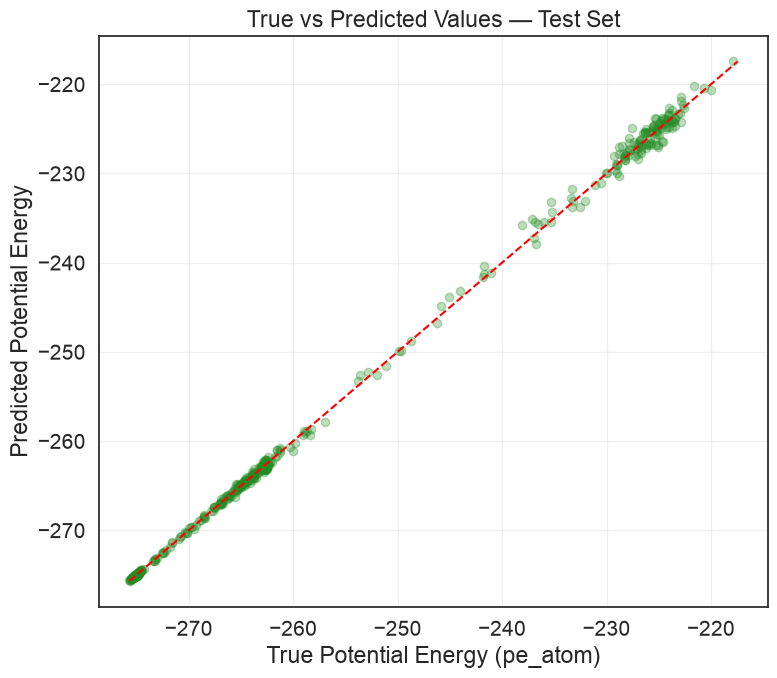

In [ ]:
# Calculate overall test metrics for regression
test_mae = mean_absolute_error(test_targets, test_preds)
test_mse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_r2 = r2_score(test_targets, test_preds)

print(f"Mean Absolute Error (MAE) over the test set: {test_mae:.4f}")
print(f"Root Mean Squared Error (RMSE) over the test set:  {test_mse:.4f}")
print(f"R-squared (R2) score over the test set:      {test_r2:.4f}")
print(f"Root Mean Squared Error (RMSE) per atom over the test set:  {test_mse/n_atoms * 1000:.4f} meV/atom")

# Generate Scatter Plot: True vs Predicted for the Test Set
plt.figure(figsize=(8, 7))
# Using a different color (e.g., forestgreen) to distinguish from the validation plot
plt.scatter(test_targets, test_preds, alpha=0.3, color='forestgreen')

# Plot the ideal prediction line (y = x) where true == predicted
min_val = min(test_targets.min(), test_preds.min())
max_val = max(test_targets.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Test Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save experiment results to history.txt
with open('history.txt', 'a') as f:
    f.write(f"{experiment_name}\tRMSE: {test_mse:.4f}\n")

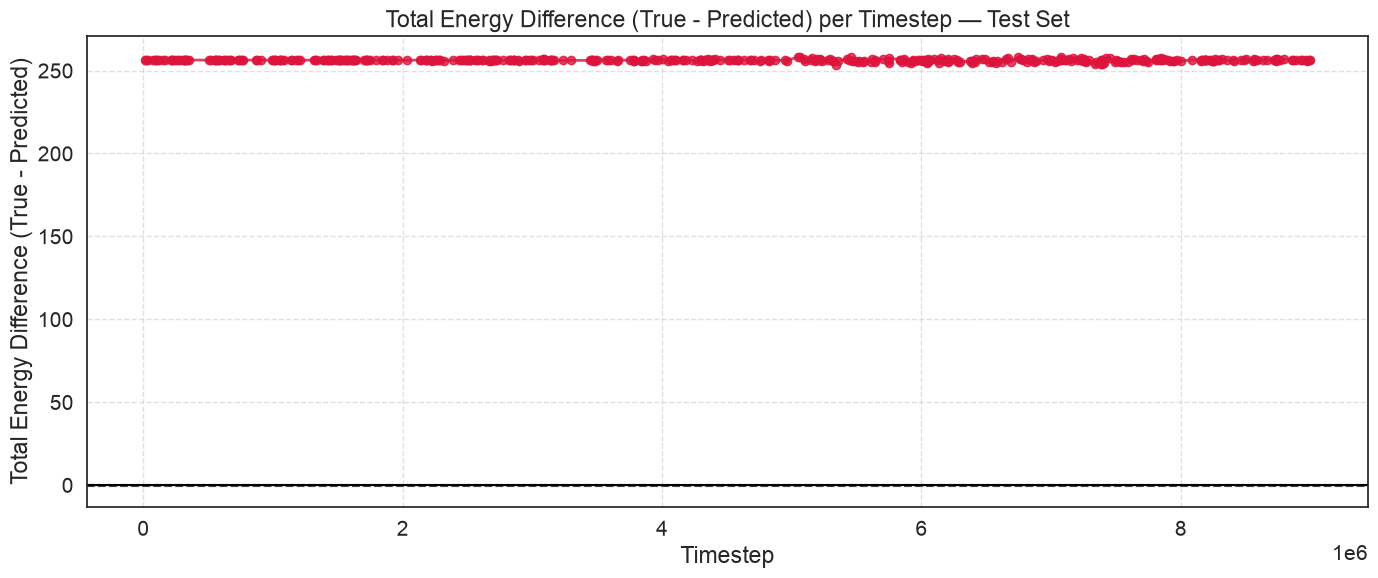

Frame-Level Total Energy Error Statistics:


count    451.000000
mean     256.273905
std        0.546638
min      253.646802
25%      256.155391
50%      256.301085
75%      256.464478
max      258.246966
Name: energy_diff, dtype: float64

In [ ]:
# 1. Recupera i timestep per l'asse X
test_timesteps = test_df.groupby('frame_id')['timestep'].first().values

# 2. Usa i valori FISICI (reali), ignorando lo shift usato per l'addestramento
# Presumendo che test_preds contenga le predizioni grezze del modello
test_preds_physical = test_preds.flatten() + mean_total_energy 

# 3. Crea il DataFrame con i valori fisici corretti
energy_per_timestep = pd.DataFrame({
    'timestep': test_timesteps, 
    'true_energy': y_test_total.flatten(),       # <- Energia fisica reale
    'predicted_energy': test_preds_physical      # <- Energia predetta reale
}).sort_values('timestep')

# 4. Calcola la differenza (che rimarrà identica, ma le colonne sopra avranno senso)
energy_per_timestep['energy_diff'] = energy_per_timestep['true_energy'] - energy_per_timestep['predicted_energy']

# --- Il resto del codice (grafico e tolleranze) rimane IDENTICO ---
plt.figure(figsize=(14, 6))
plt.plot(
    energy_per_timestep['timestep'],
    energy_per_timestep['energy_diff'],
    marker='o',
    linestyle='-',
    color='crimson',
    linewidth=2,
    alpha=0.8
)

n_atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))

# Soglia di accuratezza chimica (es. 5 meV/atomo)
lower_obj = - 5e-3 * n_atoms_per_frame
upper_obj = 5e-3 * n_atoms_per_frame

plt.axhspan(lower_obj, upper_obj, color='lightgray', alpha=0.3)
plt.axhline(y=lower_obj, color='black', linestyle='--', alpha=0.7)
plt.axhline(y=upper_obj, color='black', linestyle='--', alpha=0.7)

plt.axhline(y=0, color='black', linestyle='-', alpha=1.0)

plt.title('Total Energy Difference (True - Predicted) per Timestep — Test Set')
plt.xlabel('Timestep')
plt.ylabel('Total Energy Difference (True - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Frame-Level Total Energy Error Statistics:")
display(energy_per_timestep['energy_diff'].describe())

In [ ]:
print("Numero totale di righe (atomi):", len(data))
print("Timestep unici presenti:", data['timestep'].nunique())

Numero totale di righe (atomi): 576064
Timestep unici presenti: 9001
